# Exploratory Data Analysis.

---

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
data = pd.read_csv("spam_messages.csv")

In [3]:
data.sample(10)

,MessageID,Message,Label,CharacterCount,WordCount,HasURL,HasNumber,UppercaseRatio
436,11376,You have WON a guaranteed prize. Call now to r...,spam,83.0,16.0,0,0,0.136364
450,10353,NaN,ham,51.0,9.0,0,0,0.024390
1701,11731,I have attached the document we discussed.,ham,42.0,7.0,0,0,0.028571
537,11898,Congratulations winner! Claim your cash bonus ...,spam,80.0,11.0,0,1,0.051724
885,10668,You have WON a guaranteed prize. Call now to r...,spam,96.0,16.0,0,1,0.118644
954,11322,Let me know when you arrive. Take care.,ham,39.0,8.0,0,0,0.066667
985,10258,Thanks for helping me with the project yesterd...,ham,67.0,11.0,0,0,0.036364
1261,10735,Are you free this weekend? We could watch a mo...,ham,50.0,10.0,0,0,0.051282
48,11364,Exclusive offer! Get a FREE gift today. Limite...,spam,58.0,10.0,0,0,0.152174
821,10682,"Hey, are we still meeting for lunch today?",ham,42.0,8.0,0,0,0.030303


In [4]:
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

Rows: 2025
Columns: 8


In [5]:
print(f"Missing Values(%):\n{((data.isna().sum() / len(data)).round(4) * 100).sort_values(ascending=False)}")

Missing Values(%):
Message           2.07
CharacterCount    2.02
WordCount         1.93
MessageID         0.00
Label             0.00
HasURL            0.00
HasNumber         0.00
UppercaseRatio    0.00
dtype: float64


In [6]:
duplicate_messages = data['Message'].duplicated().sum()

print(f"Duplicated Messages: {duplicate_messages}")

Duplicated Messages: 1749


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MessageID       2025 non-null   int64  
 1   Message         1983 non-null   object 
 2   Label           2025 non-null   object 
 3   CharacterCount  1984 non-null   float64
 4   WordCount       1986 non-null   float64
 5   HasURL          2025 non-null   int64  
 6   HasNumber       2025 non-null   int64  
 7   UppercaseRatio  2025 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 126.7+ KB


Label
ham     1515
spam     510
Name: count, dtype: int64


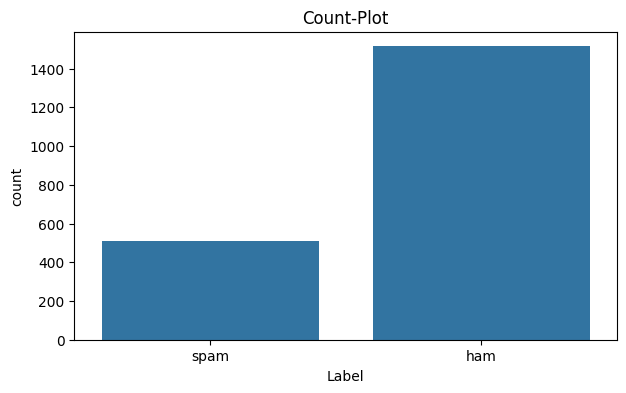

In [8]:
print(data['Label'].value_counts())

plt.figure(figsize=(7,4))

sns.countplot(data=data, x='Label')
plt.title("Count-Plot")

plt.show()

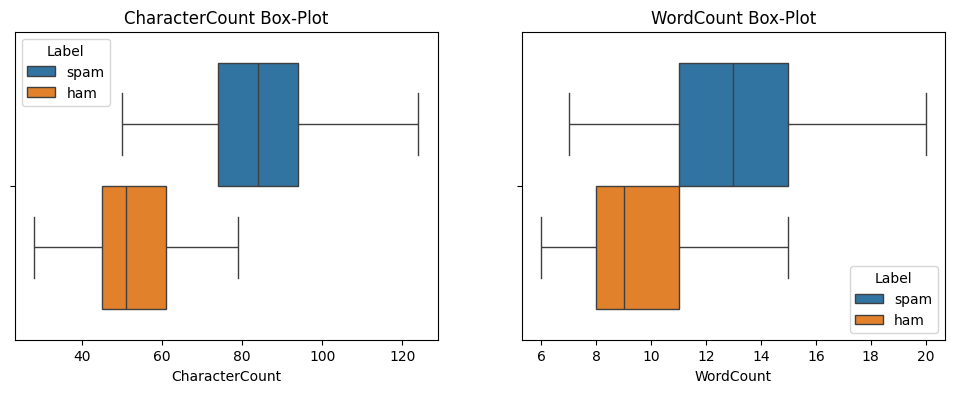

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

sns.boxplot(data=data, x='CharacterCount', hue='Label', ax=ax[0])
ax[0].set_title("CharacterCount Box-Plot")

sns.boxplot(data=data, x='WordCount', hue='Label', ax=ax[1])
plt.title("WordCount Box-Plot")

plt.show()

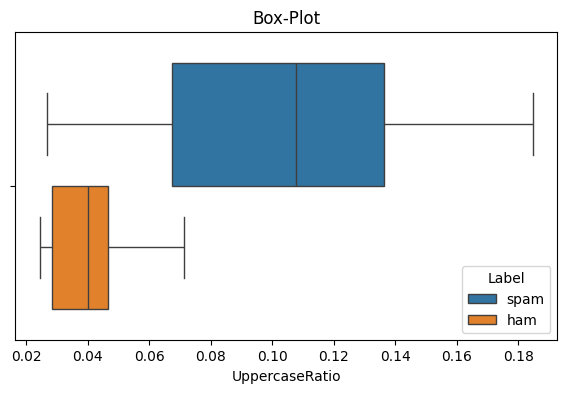

In [10]:
plt.figure(figsize=(7,4))

sns.boxplot(data=data, x='UppercaseRatio', hue='Label')
plt.title("Box-Plot")

plt.show()

In [11]:
(pd.crosstab(index=data['Label'], columns=data['HasURL'], normalize='index') * 100).round(2)

HasURL,0,1
Label,,
ham,100.00,0.00
spam,74.12,25.88


In [12]:
(pd.crosstab(index=data['Label'], columns=data['HasNumber'], normalize='index') * 100).round(2)

HasNumber,0,1
Label,,
ham,90.17,9.83
spam,71.37,28.63


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

df = data[['Message', 'Label']]

df.dropna(inplace=True)

df.drop_duplicates(subset=['Message'], keep='first', inplace=True)

df['Message'] = df['Message'].str.lower().str.strip().str.replace(r'https?://\S+|www\.\S+', 'URL', regex=True)
df['Message'] = df['Message'].str.replace(r'\b\d{7,15}\b', 'Phone-Number', regex=True)

X = df['Message']
y = df['Label']

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

vocabulary = vectorizer.get_feature_names_out()
X = X.toarray()

X_df = pd.DataFrame(X, columns=vocabulary)

y = y.reset_index(drop=True)

new_df = pd.concat([X_df, y], axis=1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3372\405980303.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_3372\405980303.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(subset=['Message'], keep='first', inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_3372\405980303.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/index

In [14]:
spam_words = new_df[new_df['Label'] == 'spam'].drop(columns=['Label']).sum()
ham_words = new_df[new_df['Label'] == 'ham'].drop(columns=['Label']).sum()

words_count = pd.DataFrame({'Spam Words' : spam_words,
                           'Ham Words' : ham_words})

top_spam = (words_count['Spam Words'].sort_values(ascending=False).head(10))
top_ham = (words_count['Ham Words'].sort_values(ascending=False).head(10))

print(f"Spam Words:\n{top_spam.to_dict()}")
print("\n")
print(f"Ham Words:\n{top_ham.to_dict()}")

Spam Words:
{'claim': 109, 'offer': 91, 'number': 89, 'expires': 77, 'today': 74, 'reward': 71, 'immediately': 69, 'phone': 69, 'click': 68, 'cash': 63}


Ham Words:
{'tomorrow': 30, 'thanks': 30, 'know': 29, 'meeting': 27, 'let': 19, 'yesterday': 18, 'home': 18, 'soon': 10, 'later': 10, 'letting': 10}


---

# Summary:

- **Target Feature:** *Label*.

- **Input Features:**
| Feature | Feature Engineering |
| - | - |
| MessageID | Drop |
| CharacterCount | Drop |
| WordCount | Drop |
| HasURL | Drop |
| HasNumber | Drop |
| UppercaseRatio | Drop |
| Message | Clean + SimpleImputer(most_frequent) + [Count-Vectorizer and TF-IDF] | 

- Dataset is **Imbalance**.

- Dataset has many *duplicated values* ~(1749).